<a href="https://colab.research.google.com/github/gautamkushwaha/M.-Tech-_Second_Year/blob/main/OCR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Image of Text→Machine Readable Text

Steps:

- Image acquisition

- Preprocessing (grayscale + thresholding)

- Segmentation (lines → words → characters)

- Feature extraction

- Classification

- Post-processing (language model)





lets do from ocr : digit recognition

In [3]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms

# load dataset
transform = transforms.ToTensor()

train_dataset = torchvision.datasets.MNIST(root='./data', train=True, transform=transform, download=True)

train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=100, shuffle=True)

In [10]:
class SimpleOCR(nn.Module):
  def __init__(self):
    super(SimpleOCR, self).__init__()
    self.fc1 = nn.Linear(28*28, 128)
    self.relu = nn.ReLU()
    self.fc2 = nn.Linear(128, 10)

  def forward(self, x):
    x = x.view(-1, 28*28)
    x = self.relu(self.fc1(x))
    x = self.fc2(x)
    return x

model = SimpleOCR()


In [14]:
# Train
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

num_epochs = 3
loss_list = []

for epoch in range(num_epochs):
  for i, (images, labels) in enumerate(train_loader):
    outputs = model(images)
    loss = criterion(outputs, labels)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

  loss_list.append(loss.item())
  print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

Epoch [1/3], Loss: 0.1888
Epoch [2/3], Loss: 0.0430
Epoch [3/3], Loss: 0.0271


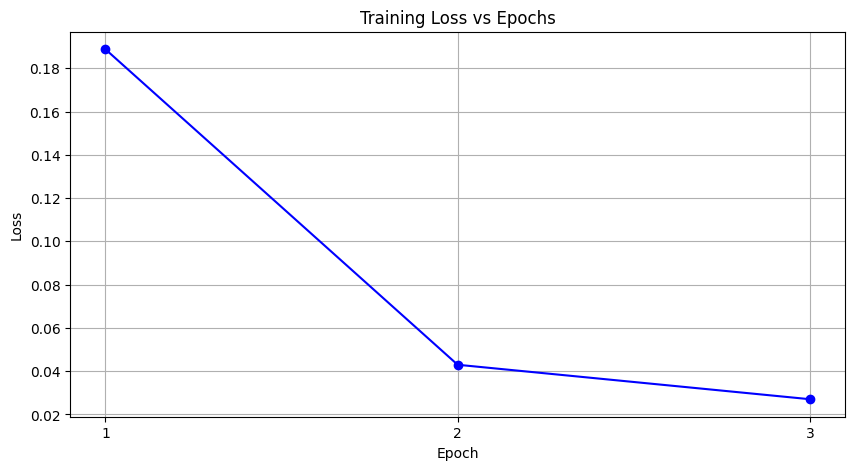

In [18]:
import matplotlib.pyplot as plt

# Plotting the graph
plt.figure(figsize=(10, 5))
plt.plot(range(1, num_epochs + 1), loss_list, marker='o', color='b', linestyle='-')
plt.title('Training Loss vs Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.xticks(range(1, num_epochs + 1))
plt.grid(True)
plt.show()

In [28]:
# CNN Model OCR
class CNNOCR(nn.Module):
  def __init__(self):
    super(CNNOCR, self).__init__()
    self.conv = nn.Sequential(
        nn.Conv2d(1, 32, 3),
        nn.ReLU(),
        nn.MaxPool2d(2),
        nn.Conv2d(32, 64, 3),
        nn.ReLU(),
        nn.MaxPool2d(2)
    )

    self.fc = nn.Linear(64*5*5, 10)

  def forward(self, x):
    x = self.conv(x)
    # The fix: separate arguments for batch size and flattening
    x = x.view(x.size(0), -1)
    x = self.fc(x)

    return x

In [29]:
model1 = CNNOCR()

In [30]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model1.parameters(), lr=0.001)

num_epochs = 3
loss_list = []

for epoch in range(num_epochs):
  for i, (images, labels) in enumerate(train_loader):
    outputs = model1(images)
    loss = criterion(outputs, labels)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

  loss_list.append(loss.item())
  print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

Epoch [1/3], Loss: 0.1300
Epoch [2/3], Loss: 0.0329
Epoch [3/3], Loss: 0.0438


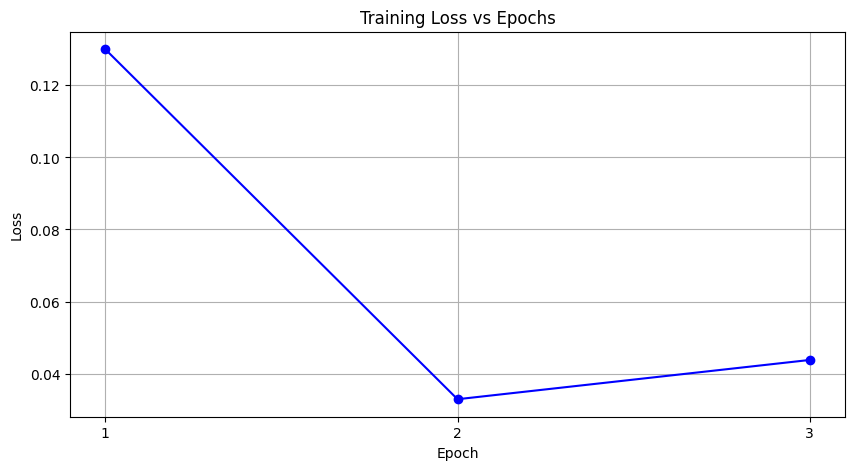

In [31]:
import matplotlib.pyplot as plt

# Plotting the graph
plt.figure(figsize=(10, 5))
plt.plot(range(1, num_epochs + 1), loss_list, marker='o', color='b', linestyle='-')
plt.title('Training Loss vs Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.xticks(range(1, num_epochs + 1))
plt.grid(True)
plt.show()